# Interpreting Climate Representations in GPT-2 via Sparse Autoencoders
> #### **Project Goal** : Large language models such as GPT-2 encode rich semantic representations across their transformer layers, yet the internal structure of these representations remains largely opaque acting as a “Black box”. This work applies Sparse Autoencoder (SAE) analysis to investigate how climate-related concepts are encoded within the intermediate activations of GPT-2 Medium.
>
> #### Drawing on the ClimateEval dataset, which spans three distinct linguistic registers Scientific, Wikipedia, and Financial we collect token-level activations from layer 17 of GPT-2 Medium and train an SAE to decompose the dense 4096-dimensional MLP output vectors into a sparse set of interpretable features. By leveraging the multi-register structure of ClimateEval, we examine whether distinct SAE features emerge for climate concepts across different discourse contexts, and whether register-selective features can be identified that capture domain-specific language patterns such as scientific hedging, ESG financial reporting, and encyclopedic climate description.


In [1]:
!pip install -q transformers datasets accelerate einops tqdm

In [2]:
# extract_gpt2_mlp_activations.py
import os
import torch
import numpy as np
import pandas as pd
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset
from tqdm import tqdm
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
SAVE_DIR     = "/content/drive/MyDrive/Colab Notebooks/SLDS_Project/token_activations"
TARGET_LAYER = 17
MODEL_NAME   = "gpt2-medium"
MAX_SENTENCES = 30_000

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


## Extraction Of GPT-2 Actiavtion

In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
model.eval().to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/718 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.52G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2-medium
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...23}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 1024)
    (wpe): Embedding(1024, 1024)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-23): 24 x GPT2Block(
        (ln_1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=3072, nx=1024)
          (c_proj): Conv1D(nf=1024, nx=1024)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=4096, nx=1024)
          (c_proj): Conv1D(nf=1024, nx=4096)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=1024, out_features=50257, bias=False)
)

In [5]:
target_block = model.transformer.h[TARGET_LAYER]
print(f"Hooked layer: {TARGET_LAYER}")
print(f"Model hidden size: {model.config.hidden_size}")

Hooked layer: 17
Model hidden size: 1024


In [6]:
print(f"\n{'='*80}")
print("Model Architecture Summary")
print(f"{'='*80}")

print(f"\nModel Type: {model.config.model_type}")
print(f"\nModel Name: gpt2-medium")

print(f"\nNumber of Transformer Layers: {model.config.n_layer}")

print(f"\nHidden Size (Embedding Dimension): {model.config.n_embd}")

print(f"\nNumber of Attention Heads: {model.config.n_head}")

print(f"\nHead Dimension: {model.config.n_embd // model.config.n_head}")

ffn_size = model.config.n_inner or 4 * model.config.n_embd
print(f"\nIntermediate Feed Forward Network Size: {ffn_size}")

print(f"\nMaximum Position Embeddings: {model.config.n_positions}")

print(f"\nVocabulary Size: {model.config.vocab_size}")

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal Parameters: {total_params:,}")

print(f"\nToken Embedding Shape: {model.transformer.wte.weight.shape}")
print(f"\nPosition Embedding Shape: {model.transformer.wpe.weight.shape}")

print(f"\n{'='*80}")


Model Architecture Summary

Model Type: gpt2

Model Name: gpt2-medium

Number of Transformer Layers: 24

Hidden Size (Embedding Dimension): 1024

Number of Attention Heads: 16

Head Dimension: 64

Intermediate Feed Forward Network Size: 4096

Maximum Position Embeddings: 1024

Vocabulary Size: 50257

Total Parameters: 354,823,168

Token Embedding Shape: torch.Size([50257, 1024])

Position Embedding Shape: torch.Size([1024, 1024])



### Example To Get Activation

In [7]:
# ── single sentence test ──────────────────────────────────────────────────────
sentence = "Global temperatures have risen significantly due to greenhouse gas emissions."

residual_store = {}
mlp_store      = {}

In [8]:
def hook_residual(module, input, output):
    residual_store["act"] = output.detach().cpu()

def hook_mlp(module, input, output):
    # output = post-GELU activation
    mlp_store["act"] = output.detach().cpu()

In [9]:
h1 = target_block.ln_2.register_forward_hook(hook_residual)
h2 = target_block.mlp.act.register_forward_hook(hook_mlp)

In [10]:
inputs = tokenizer(sentence, return_tensors="pt").to(device)
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

with torch.no_grad():
    model(**inputs)

h1.remove()
h2.remove()

In [11]:
res = residual_store["act"].squeeze(0)
mlp = mlp_store["act"].squeeze(0)

print(f"Tokens:         {tokens}")
print(f"Residual shape: {res.shape}")
print(f"MLP shape:      {mlp.shape}")
print()
print(f"{'Token':<20} {'Residual L2':>12}  {'MLP L2':>10}")
print("-" * 46)
for i, tok in enumerate(tokens):
    print(f"{tok:<20} {res[i].norm().item():>12.3f}  {mlp[i].norm().item():>10.3f}")

Tokens:         ['Global', 'Ġtemperatures', 'Ġhave', 'Ġrisen', 'Ġsignificantly', 'Ġdue', 'Ġto', 'Ġgreenhouse', 'Ġgas', 'Ġemissions', '.']
Residual shape: torch.Size([11, 1024])
MLP shape:      torch.Size([11, 4096])

Token                 Residual L2      MLP L2
----------------------------------------------
Global                      6.646       6.501
Ġtemperatures               6.948      11.768
Ġhave                       7.192      16.285
Ġrisen                      7.788      14.447
Ġsignificantly              7.298      12.302
Ġdue                        7.903      13.039
Ġto                         7.349      15.260
Ġgreenhouse                 8.056      12.786
Ġgas                        8.068      15.513
Ġemissions                  7.334      11.161
.                           5.938      12.152


### Load ClimateEval

In [12]:
ds_climate = load_dataset("murathankurfali/ClimateEval", split="train")

climate_dataset = pd.DataFrame(ds_climate, columns=['label', 'sentence'])
climate_dataset.head()

clima_text/train-data/AL-10Ks.tsv : 3000(…):   0%|          | 0.00/534k [00:00<?, ?B/s]

clima_text/train-data/AL-Wiki (train).ts(…):   0%|          | 0.00/451k [00:00<?, ?B/s]

clima_text/train-data/Wiki-Doc-Train.tsv:   0%|          | 0.00/19.4M [00:00<?, ?B/s]

clima_text/dev-data/Wiki-Doc-Dev.tsv:   0%|          | 0.00/603k [00:00<?, ?B/s]

clima_text/dev-data/Wikipedia (dev).tsv:   0%|          | 0.00/53.3k [00:00<?, ?B/s]

...

clima_text/test-data/Wikipedia (test).ts(…):   0%|          | 0.00/51.7k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/121847 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3918 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5426 [00:00<?, ? examples/s]

,label,sentence
0,0,• collection of debts from loan customers wh...
1,0,"All known, material risks and uncertainties ar..."
2,1,Although it is not possible at this time to pr...
3,0,"Ifthere is a decline in real estate values, as..."
4,0,Our expenses have exceeded ourrevenue since in...


In [13]:
climate_dataset.shape

(121847, 2)

In [14]:
climate_texts = climate_dataset["sentence"].tolist()
climate_labels = climate_dataset["label"].tolist()

In [15]:
climate_texts = climate_texts[:MAX_SENTENCES]
climate_labels = climate_labels[:MAX_SENTENCES]

### Hook setup

In [16]:
residual_pre_mlp = {}
mlp_activations  = {}

def hook_residual_pre_mlp(module, input):
    residual_pre_mlp[0] = input[0].detach().cpu()

def hook_mlp_post_gelu(module, input, output):
    mlp_activations[0] = output.detach().cpu()

hooks = []
hooks.append(target_block.ln_2.register_forward_pre_hook(hook_residual_pre_mlp))
hooks.append(target_block.mlp.act.register_forward_hook(hook_mlp_post_gelu))

print(f"Hooks registered on layer {TARGET_LAYER}")

Hooks registered on layer 17


### Collect and Store Activations Per Token

In [19]:
all_activations = []

for sent in tqdm(climate_texts):
    residual_pre_mlp.clear()
    mlp_activations.clear()

    inputs = tokenizer(
        sent,
        return_tensors="pt",
        truncation=True,
    ).to(device)

    with torch.no_grad():
        model(**inputs)

    res_tensor = residual_pre_mlp[0].squeeze(0)
    mlp_tensor = mlp_activations[0].squeeze(0)

    token_dict = {}
    for i, token_id in enumerate(inputs.input_ids[0]):
        token = tokenizer.decode(token_id)
        token_dict[i] = {
            "token":           token,
            "residual_pre_mlp": res_tensor[i].numpy(),
            "mlp_post_full":    mlp_tensor[i].numpy(),
            "sentence":         sent[:200]
        }

    all_activations.append((sent, token_dict))

# remove hooks
for h in hooks:
    h.remove()

print(f"Done! Collected activations for {len(all_activations):,} sentences")

100%|██████████| 30000/30000 [11:05<00:00, 45.07it/s]

Done! Collected activations for 30,000 sentences


In [20]:
residuals_list    = []
mlp_list          = []
tokens_list       = []
sentence_idx_list = []
position_idx_list = []
label_list        = []

for sent_idx, (sentence, pos_dict) in enumerate(all_activations):
    for pos_idx, token_info in pos_dict.items():
        residuals_list.append(token_info["residual_pre_mlp"])
        mlp_list.append(token_info["mlp_post_full"])
        tokens_list.append(token_info["token"])
        sentence_idx_list.append(sent_idx)
        position_idx_list.append(pos_idx)
        label_list.append(climate_labels[sent_idx])

residuals_tensor     = torch.tensor(np.stack(residuals_list), dtype=torch.float32)
mlp_tensor           = torch.tensor(np.stack(mlp_list),       dtype=torch.float32)
sentence_idx_tensor  = torch.tensor(sentence_idx_list,        dtype=torch.long)
position_idx_tensor  = torch.tensor(position_idx_list,        dtype=torch.long)
label_tensor         = torch.tensor(label_list,               dtype=torch.long)

print(f"residuals_tensor:  {residuals_tensor.shape}")
print(f"mlp_tensor:        {mlp_tensor.shape}")
print(f"Total tokens:      {residuals_tensor.shape[0]:,}")
print(f"Unique sentences:  {len(all_activations):,}")
print(f"Avg tokens/sent:   {residuals_tensor.shape[0]/len(all_activations):.1f}")

residuals_tensor:  torch.Size([839773, 1024])
mlp_tensor:        torch.Size([839773, 4096])
Total tokens:      839,773
Unique sentences:  30,000
Avg tokens/sent:   28.0


### Store Activation to Drive

In [21]:
os.makedirs(SAVE_DIR, exist_ok=True)

output_file = f"{SAVE_DIR}/climateeval_gpt2_layer{TARGET_LAYER}_activations.pt"

In [22]:
torch.save({
    "residuals_post_attn": residuals_tensor,
    "mlp_post_full":       mlp_tensor,
    "tokens":              tokens_list,
    "sentence_idx":        sentence_idx_tensor,
    "position_idx":        position_idx_tensor,
    "labels":              label_tensor,
    "layer":               TARGET_LAYER,
    "model":               MODEL_NAME,
}, output_file)

print(f"Saved to: {output_file}")

Saved to: /content/drive/MyDrive/Colab Notebooks/SLDS_Project/token_activations/climateeval_gpt2_layer17_activations.pt


In [23]:
print(mlp_tensor.shape)
print(mlp_tensor.device)

torch.Size([839773, 4096])
cpu


## **SAE Training**

In [24]:
#Session specific loading
#data = torch.load(f"{SAVE_DIR}/climateeval_gpt2_layer17_activations.pt")
#mlp_tensor   = data["mlp_post_full"]
#tokens_list  = data["tokens"]
#label_tensor = data["labels"]

print(f"Loaded: {mlp_tensor.shape}")

Loaded: torch.Size([839773, 4096])


In [25]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SparseAutoencoder(nn.Module):
    def __init__(self, input_dim, dict_size):
        super().__init__()
        self.input_dim = input_dim
        self.dict_size = dict_size

        # encoder
        self.W_enc = nn.Parameter(torch.empty(input_dim, dict_size))
        self.b_enc = nn.Parameter(torch.zeros(dict_size))

        # decoder
        self.W_dec = nn.Parameter(torch.empty(dict_size, input_dim))
        self.b_dec = nn.Parameter(torch.zeros(input_dim))

        # initialize
        nn.init.kaiming_uniform_(self.W_enc)
        nn.init.kaiming_uniform_(self.W_dec)
        self._normalize_decoder()

    @torch.no_grad()
    def _normalize_decoder(self):
        norms = self.W_dec.norm(dim=1, keepdim=True).clamp(min=1.0)
        self.W_dec.data /= norms

    def encode(self, x):
        x_c    = x - self.b_dec
        pre    = x_c @ self.W_enc + self.b_enc
        return F.relu(pre)

    def decode(self, f):
        return f @ self.W_dec + self.b_dec

    def forward(self, x):
        f     = self.encode(x)
        x_hat = self.decode(f)
        return f, x_hat

    def loss(self, x, f, x_hat, l1_coeff):
        recon = ((x - x_hat) ** 2).sum(dim=-1).mean()
        l1    = f.abs().sum(dim=-1).mean()
        total = recon + l1_coeff * l1
        return total, recon, l1

# sanity check
INPUT_DIM = 4096
DICT_SIZE = 32768   # 8x expansion

sae_test = SparseAutoencoder(INPUT_DIM, DICT_SIZE)
dummy    = torch.randn(4, INPUT_DIM)
f, x_hat = sae_test(dummy)
print(f"SAE sanity check passed!")
print(f"input:  {dummy.shape}")
print(f"features: {f.shape}")      # (4, 32768)
print(f"reconstruction: {x_hat.shape}")  # (4, 4096)

SAE sanity check passed!
input:  torch.Size([4, 4096])
features: torch.Size([4, 32768])
reconstruction: torch.Size([4, 4096])


### Training Config

In [26]:
from torch.utils.data import DataLoader, TensorDataset

# config
INPUT_DIM  = 4096
DICT_SIZE  = 32768    # 8x expansion
L1_COEFF   = 0.4
LR         = 1e-4
BATCH_SIZE = 2048
EPOCHS     = 10
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

# dataset
dataset    = TensorDataset(mlp_tensor)
loader     = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0        # 0 for Colab
)

print(f"Training samples: {len(dataset):,}")
print(f"Batches per epoch: {len(loader):,}")
print(f"Input dim: {INPUT_DIM}")
print(f"Dict size: {DICT_SIZE}")

Using device: cuda
Training samples: 839,773
Batches per epoch: 411
Input dim: 4096
Dict size: 32768


### Training Loop

In [27]:
import json
from tqdm import tqdm

# initialize
sae       = SparseAutoencoder(INPUT_DIM, DICT_SIZE).to(DEVICE)
optimizer = torch.optim.Adam(sae.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS * len(loader)
)

history = []
print(f"Training SAE on {DEVICE}...")
print(f"Total tokens: {len(dataset):,}")
print(f"Dict size: {DICT_SIZE} features")
print("-" * 60)

for epoch in range(EPOCHS):
    epoch_total = 0
    epoch_recon = 0
    epoch_l1    = 0
    mean_active = 0

    pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for batch in pbar:
        x = batch[0].to(DEVICE)

        f, x_hat               = sae(x)
        loss, recon, l1        = sae.loss(x, f, x_hat, L1_COEFF)

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(sae.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        # keep decoder unit norm
        sae._normalize_decoder()

        epoch_total += loss.item()
        epoch_recon += recon.item()
        epoch_l1    += l1.item()
        mean_active += (f > 0).float().sum(dim=-1).mean().item()

        pbar.set_postfix(
            loss  = f"{loss.item():.4f}",
            recon = f"{recon.item():.4f}",
            l1    = f"{l1.item():.4f}",
            active= f"{(f > 0).float().sum(dim=-1).mean().item():.1f}"
        )

    n = len(loader)
    stats = {
        "epoch":       epoch + 1,
        "loss":        epoch_total / n,
        "recon":       epoch_recon / n,
        "l1":          epoch_l1    / n,
        "mean_active": mean_active / n
    }
    history.append(stats)
    print(f"\nEpoch {epoch+1} Summary:")
    print(f"  loss={stats['loss']:.4f} | recon={stats['recon']:.4f} | "
          f"l1={stats['l1']:.4f} | avg_active_features={stats['mean_active']:.1f}")

Training SAE on cuda...
Total tokens: 839,773
Dict size: 32768 features
------------------------------------------------------------


Epoch 1/10: 100%|██████████| 411/411 [01:36<00:00,  4.25it/s, active=196.0, l1=35.8990, loss=92.4974, recon=78.1378]



Epoch 1 Summary:
  loss=115.5195 | recon=101.7170 | l1=34.5063 | avg_active_features=285.9


Epoch 2/10: 100%|██████████| 411/411 [01:36<00:00,  4.24it/s, active=239.9, l1=42.7080, loss=85.8523, recon=68.7691]



Epoch 2 Summary:
  loss=81.5523 | recon=66.5631 | l1=37.4730 | avg_active_features=207.5


...


Epoch 8 Summary:
  loss=60.9294 | recon=45.1282 | l1=39.5030 | avg_active_features=230.6


Epoch 9/10: 100%|██████████| 411/411 [01:37<00:00,  4.23it/s, active=216.7, l1=39.1301, loss=58.0991, recon=42.4470]



Epoch 9 Summary:
  loss=60.5745 | recon=44.7723 | l1=39.5055 | avg_active_features=230.5


Epoch 10/10: 100%|██████████| 411/411 [01:36<00:00,  4.26it/s, active=240.8, l1=41.4942, loss=63.9901, recon=47.3924]


Epoch 10 Summary:
  loss=60.4729 | recon=44.6638 | l1=39.5227 | avg_active_features=230.6


### Save SAE weights immediately after training

In [28]:
import os
os.makedirs(SAVE_DIR, exist_ok=True)

# save weights (~500MB for 32768 features)
torch.save(
    sae.state_dict(),
    f"{SAVE_DIR}/sae_gpt2medium_layer{TARGET_LAYER}_4096x8.pt"
)

# save config + history
config = {
    "input_dim":   INPUT_DIM,
    "dict_size":   DICT_SIZE,
    "l1_coeff":    L1_COEFF,
    "lr":          LR,
    "epochs":      EPOCHS,
    "batch_size":  BATCH_SIZE,
    "model":       "gpt2-medium",
    "layer":       TARGET_LAYER,
    "hook_point":  "mlp_post_gelu_4096",
    "n_tokens":    len(dataset),
    "history":     history
}

with open(f"{SAVE_DIR}/sae_config.json", "w") as f:
    json.dump(config, f, indent=2)

print(f"SAE weights saved!")
print(f"features: {DICT_SIZE}")
print(f"trained on: {len(dataset):,} tokens")

SAE weights saved!
features: 32768
trained on: 839,773 tokens


## Feature Interpretation

###Load SAE and compute feature activations

In [29]:
import numpy as np
from collections import defaultdict
from collections import Counter

# make sure sae is loaded (if session died reload with):
#sae = SparseAutoencoder(INPUT_DIM, DICT_SIZE).to(device)
#sae.load_state_dict(torch.load(f"{SAVE_DIR}/sae_gpt2medium_layer{TARGET_LAYER}_4096x8.pt"))
#sae.eval()

In [30]:
print("Computing feature activations...")

# running stats - don't store full matrix!
feature_sum      = torch.zeros(DICT_SIZE)
feature_sq_sum   = torch.zeros(DICT_SIZE)
feature_nonzero  = torch.zeros(DICT_SIZE)
total_tokens     = 0

# for top token analysis - store only top activations per feature
top_vals    = torch.zeros(DICT_SIZE, 20)   # top 20 values per feature
top_indices = torch.zeros(DICT_SIZE, 20, dtype=torch.long)

with torch.no_grad():
    for i in tqdm(range(0, len(mlp_tensor), 2048)):
        batch = mlp_tensor[i:i+2048].to(DEVICE)
        f, _  = sae(batch)
        f     = f.cpu()

        n = f.shape[0]
        feature_sum     += f.sum(0)
        feature_sq_sum  += (f**2).sum(0)
        feature_nonzero += (f > 0).float().sum(0)
        total_tokens    += n

        # update top activating tokens per feature
        combined_vals    = torch.cat([top_vals, f.T], dim=1)
        combined_indices = torch.cat([
            top_indices,
            torch.arange(i, i+n).unsqueeze(0).expand(DICT_SIZE, -1)
        ], dim=1)

        top_k = combined_vals.topk(20, dim=1)
        top_vals    = top_k.values
        top_indices = combined_indices.gather(1, top_k.indices)

        # free GPU memory immediately
        del f, batch
        torch.cuda.empty_cache()

# compute final stats
mean_act   = feature_sum / total_tokens
frac_active = feature_nonzero / total_tokens

print(f"Done! Processed {total_tokens:,} tokens")
print(f"Mean activation: {mean_act.mean():.4f}")
print(f"Frac active:     {frac_active.mean():.4f}")

Computing feature activations...


100%|██████████| 411/411 [05:36<00:00,  1.22it/s]

Done! Processed 839,773 tokens
Mean activation: 0.0012
Frac active:     0.0070


### Dead Feature Analysis

In [31]:
dead_thresh = 1e-4
n_dead      = (frac_active < dead_thresh).sum().item()
n_alive     = (frac_active >= dead_thresh).sum().item()

print(f"=== Dead Feature Analysis ===")
print(f"Total features:  {DICT_SIZE:,}")
print(f"Dead features:   {n_dead:,}  ({100*n_dead/DICT_SIZE:.1f}%)")
print(f"Alive features:  {n_alive:,} ({100*n_alive/DICT_SIZE:.1f}%)")

# top 20 most active features
print(f"\n=== Top 20 Most Active Features ===")
top_features = mean_act.argsort(descending=True)[:20]
for i, feat_idx in enumerate(top_features.tolist()):
    print(f"  [{i+1:2d}] Feature {feat_idx:5d} | "
          f"mean_act={mean_act[feat_idx]:.4f} | "
          f"frac_active={frac_active[feat_idx]:.4f}")

=== Dead Feature Analysis ===
Total features:  32,768
Dead features:   12,477  (38.1%)
Alive features:  20,291 (61.9%)

=== Top 20 Most Active Features ===
  [ 1] Feature 12962 | mean_act=0.1200 | frac_active=0.0438
  [ 2] Feature 21229 | mean_act=0.0768 | frac_active=0.0357
  [ 3] Feature 21133 | mean_act=0.0461 | frac_active=0.0386
  [ 4] Feature 31528 | mean_act=0.0444 | frac_active=0.0838
  [ 5] Feature 18161 | mean_act=0.0328 | frac_active=0.0565
  [ 6] Feature 17748 | mean_act=0.0320 | frac_active=0.0864
  [ 7] Feature  6159 | mean_act=0.0290 | frac_active=0.0435
  [ 8] Feature  1338 | mean_act=0.0287 | frac_active=0.0462
  [ 9] Feature  1112 | mean_act=0.0279 | frac_active=0.0533
  [10] Feature 15719 | mean_act=0.0262 | frac_active=0.0601
  [11] Feature 15675 | mean_act=0.0256 | frac_active=0.1101
  [12] Feature 19263 | mean_act=0.0253 | frac_active=0.0877
  [13] Feature 16969 | mean_act=0.0238 | frac_active=0.0508
  [14] Feature   439 | mean_act=0.0235 | frac_active=0.0464
  [1

### Top activating tokens per feature:

In [32]:
print("=== Top Tokens Per Feature ===\n")

top_features = mean_act.argsort(descending=True)[:20].tolist()

for feat_idx in top_features:
    # get top token indices for this feature
    tok_indices = top_indices[feat_idx].tolist()
    tok_values  = top_vals[feat_idx].tolist()

    # get actual tokens and labels
    tokens      = [tokens_list[i].replace("Ġ", "").strip() for i in tok_indices]
    labels      = [label_tensor[i].item() for i in tok_indices]

    print(f"Feature {feat_idx:5d} | "
          f"mean_act={mean_act[feat_idx]:.4f} | "
          f"frac_active={frac_active[feat_idx]:.4f}")
    print(f"  Tokens: {tokens}")
    print(f"  Values: {[round(v,3) for v in tok_values]}")
    print(f"  Labels: {labels}")
    print()

=== Top Tokens Per Feature ===

Feature 12962 | mean_act=0.1200 | frac_active=0.0438
  Tokens: ['SR', 'Z', 'Z', 'Z', 'Z', 'Z', 'Z', 'Z', 'Z', 'Z', 'Z', 'Z', 'IG', 'by', 'by', 'by', 'by', 'Sov', 'GL', 'SG']
  Values: [3.382, 3.38, 3.38, 3.38, 3.38, 3.38, 3.38, 3.38, 3.38, 3.38, 3.38, 3.38, 3.379, 3.378, 3.378, 3.378, 3.378, 3.378, 3.378, 3.378]
  Labels: [1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1]

Feature 21229 | mean_act=0.0768 | frac_active=0.0357
  Tokens: ['show', 'by', 'by', 'by', 'by', 'of', 'of', 'of', 'of', 'of', 'of', 'of', 'of', 'DD', 'DD', 'DD', 'By', 'By', 'By', 'By']
  Values: [2.175, 2.173, 2.173, 2.173, 2.173, 2.173, 2.173, 2.173, 2.173, 2.173, 2.173, 2.173, 2.173, 2.172, 2.172, 2.172, 2.172, 2.172, 2.172, 2.172]
  Labels: [1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1]

Feature 21133 | mean_act=0.0461 | frac_active=0.0386
  Tokens: ['.', '.', ').', '.', '.', '.', '.', ').', '.', '.', '.', '.', '.', '.', ').', ').', '.', '.', '.', '.']
  Val

### Register selective features

In [40]:
# ── Step 1: find climate features ─────────────────────────────

SEARCH_RANGE = 500
alive_features = mean_act.argsort(descending=True)[20:SEARCH_RANGE].tolist()

climate_keywords = [
    "emission", "carbon", "climate", "temperature", "warming",
    "greenhouse", "fossil", "renewable", "sea", "arctic",
    "drought", "flood", "storm", "energy", "policy",
    "financial", "risk", "investment", "esg", "disclosure",
    "electricity", "species", "ecosystem", "ocean", "research",
    "evidence", "organism", "disease", "atmosphere", "glacier"
]

print("=== Finding Climate Features ===\n")

new_interesting_features = []

for feat_idx in alive_features:
    tok_indices = top_indices[feat_idx].tolist()
    tokens      = [tokens_list[i].replace("Ġ", "").strip().lower()
                   for i in tok_indices]
    matches     = [t for t in tokens
                   if any(k in t for k in climate_keywords)]

    # We keep the feature which consistently fires in climate-related words with 2+ matches
    if len(matches) >= 2:
        labels = [label_tensor[i].item() for i in tok_indices]
        new_interesting_features.append(feat_idx)
        print(f"Feature {feat_idx:5d} | frac_active={frac_active[feat_idx]:.4f}")
        print(f"  Tokens:  {tokens[:10]}")
        print(f"  Matches: {matches[:]}")
        print(f"  Labels:  {labels[:10]}")
        print()

print(f"\nFound {len(new_interesting_features)} climate features!")

=== Finding Climate Features ===

Feature  5942 | frac_active=0.0741
  Tokens:  ['system', 'ecology', 'environment', 'ecosystem', 'ecosystem', 'composition', 'ecosystems', 'systems', 'systems', 'resources']
  Matches: ['ecosystem', 'ecosystem', 'ecosystems', 'ecosystems', 'ecosystems', 'ecosystem', 'ecosystems', 'ecosystems', 'ecosystems']
  Labels:  [1, 1, 1, 1, 1, 1, 1, 0, 1, 1]

Feature  5138 | frac_active=0.0751
  Tokens:  ['levels', 'emissions', 'flows', 'revenues', 'flows', 'emissions', 'revenues', 'level', 'prospects', 'flow']
  Matches: ['emissions', 'emissions', 'temperatures']
  Labels:  [1, 1, 0, 0, 0, 1, 0, 1, 0, 1]

Feature 31800 | frac_active=0.0658
  Tokens:  ['molecules', 'species', 'material', 'organisms', 'minerals', 'compounds', 'compounds', 'compounds', 'materials', 'compounds']
  Matches: ['species', 'organisms']
  Labels:  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Feature  2020 | frac_active=0.0567
  Tokens:  ['organisms', 'organisms', 'species', 'organisms', 'species', 'sp

In [45]:
interesting_features = [1367, 6621, 9096, 26880, 8350, 20139, 5316, 16028, 7297, 3529, 5942, 13161, 5138, 10245, 28779, 28884]

feature_names = {
    1367:  "Carbon",
    6621:  "Carbon/Gas",
    9096:  "Temperature",
    26880: "Fossil/Ancient",
    8350:  "Arctic/Ocean",
    20139: "Climate/Temperature",
    5316:  "Electricity",
    16028: "Energy/Heat",
    7297:  "Warming/Storm",
    3529:  "Water/Atmosphere",
    5942:  "Ecosystem",
    13161: "Ecosystem/Environmental",
    5138:  "Emissions/Financial Flows",
    10245: "Research/Evidence",
    28779: "Electricity/Power",
    28884: "Season/Sector"
}

unique_labels = label_tensor.unique().tolist()

# ── collect everything into rows ──────────────────────────────────────────────
rows = []

for feat_idx in interesting_features:
    tok_indices = top_indices[feat_idx].tolist()
    feat_labels = [label_tensor[i].item() for i in tok_indices]
    feat_tokens = [tokens_list[i].replace("Ġ","").strip() for i in tok_indices]
    feat_values = top_vals[feat_idx].tolist()
    label_counts = Counter(feat_labels)

    # mean activation per label
    label_means = {}
    for lbl in unique_labels:
        lbl_mask    = (label_tensor == lbl)
        lbl_indices = lbl_mask.nonzero().squeeze().tolist()
        if isinstance(lbl_indices, int):
            lbl_indices = [lbl_indices]
        sample = lbl_indices[:1000]
        batch  = mlp_tensor[sample].to(DEVICE)
        with torch.no_grad():
            f, _ = sae(batch)
        label_means[lbl] = f[:, feat_idx].mean().item()
        del f, batch
        torch.cuda.empty_cache()

    # one row per feature
    rows.append({
        "feature_idx":        feat_idx,
        "feature_name":       feature_names[feat_idx],
        "top_tokens":         feat_tokens[:10],
        "top_values":         [round(v, 3) for v in feat_values[:10]],
        "label0_count":       label_counts.get(0, 0),
        "label1_count":       label_counts.get(1, 0),
        "label0_mean_act":    round(label_means.get(0, 0), 4),
        "label1_mean_act":    round(label_means.get(1, 0), 4),
        "frac_active":        round(frac_active[feat_idx].item(), 4),
        "mean_act":           round(mean_act[feat_idx].item(), 4),
    })

# ── build DataFrame ───────────────────────────────────────────────────────────
df = pd.DataFrame(rows)

# computed columns
df["selectivity_ratio"] = (df["label1_mean_act"] /
                            df["label0_mean_act"].replace(0, 1e-6)).round(2)
df["dominant_label"]    = df.apply(
    lambda r: "Climate" if r["label1_mean_act"] > r["label0_mean_act"]
              else "Non-Climate", axis=1
)

print(df[["feature_idx", "feature_name", "label0_mean_act",
          "label1_mean_act", "selectivity_ratio",
          "dominant_label"]].to_string(index=False))

# save to Drive
df.to_csv(f"{SAVE_DIR}/feature_analysis.csv", index=False)


 feature_idx              feature_name  label0_mean_act  label1_mean_act  selectivity_ratio dominant_label
        1367                    Carbon           0.0024           0.0033               1.38        Climate
        6621                Carbon/Gas           0.0082           0.0577               7.04        Climate
        9096               Temperature           0.0126           0.0101               0.80    Non-Climate
       26880            Fossil/Ancient           0.0049           0.0014               0.29    Non-Climate
        8350              Arctic/Ocean           0.0022           0.0004               0.18    Non-Climate
       20139       Climate/Temperature           0.0020           0.0246              12.30        Climate
        5316               Electricity           0.0094           0.0222               2.36        Climate
       16028               Energy/Heat           0.0084           0.0082               0.98    Non-Climate
        7297             Warming/Stor

In [46]:
# ── expand df to have one row per token per feature ───────────────────────────
token_rows = []

for _, row in df.iterrows():
    feat_idx    = row["feature_idx"]
    feat_name   = row["feature_name"]
    tokens      = row["top_tokens"]
    values      = row["top_values"]

    # get labels for each token
    tok_indices = top_indices[feat_idx].tolist()[:10]
    tok_labels  = [label_tensor[i].item() for i in tok_indices]

    # deduplicate tokens keeping highest activation
    seen = {}
    for tok, val, lbl in zip(tokens, values, tok_labels):
        clean_tok = tok.strip()
        if clean_tok not in seen:
            seen[clean_tok] = {"value": val, "label": lbl}

    for tok, info in seen.items():
        token_rows.append({
            "feature_idx":  feat_idx,
            "feature_name": feat_name,
            "token":        tok,
            "value":        info["value"],
            "label":        info["label"],
            "label_name":   "Climate" if info["label"] == 1 else "Non-Climate"
        })

# ── build token DataFrame ─────────────────────────────────────────────────────
df_tokens = pd.DataFrame(token_rows)

# sort by feature and value
df_tokens = df_tokens.sort_values(
    ["feature_idx", "value"], ascending=[True, False]
).reset_index(drop=True)

# keep top 8 unique tokens per feature
df_tokens = df_tokens.groupby("feature_idx").head(8).reset_index(drop=True)

print(df_tokens[["feature_idx", "feature_name",
                 "token", "value", "label_name"]])

# save to Drive
df_tokens.to_csv(f"{SAVE_DIR}/feature_top_tokens.csv", index=False)

    feature_idx      feature_name       token  value   label_name
0          1367            Carbon         ene  3.237      Climate
1          1367            Carbon      carbon  2.992      Climate
2          1367            Carbon         ine  2.783      Climate
3          3529  Water/Atmosphere       water  3.878      Climate
4          3529  Water/Atmosphere  atmosphere  3.148      Climate
..          ...               ...         ...    ...          ...
62        28884     Season/Sector     segment  2.957  Non-Climate
63        28884     Season/Sector     species  2.898      Climate
64        28884     Season/Sector      region  2.896      Climate
65        28884     Season/Sector       group  2.886      Climate
66        28884     Season/Sector      sector  2.858      Climate

[67 rows x 5 columns]



## Results Visualization


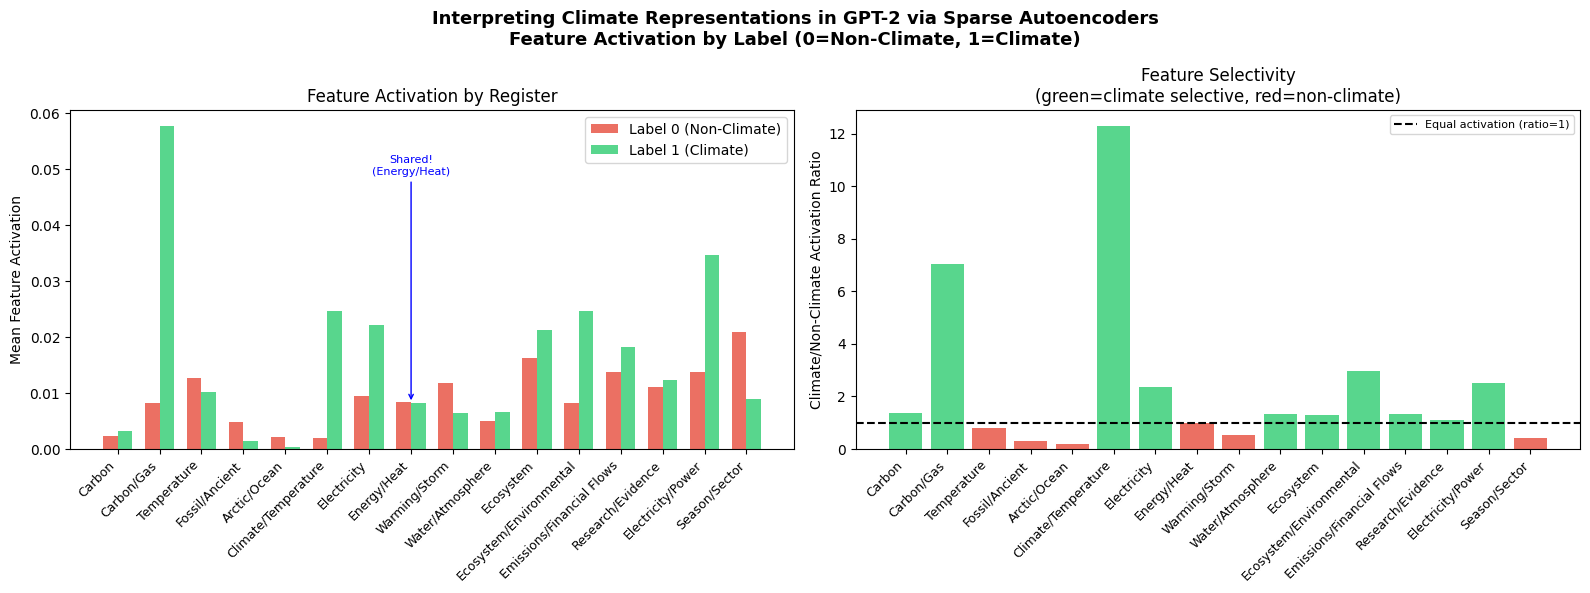

✅ Plot saved!


In [48]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    "Interpreting Climate Representations in GPT-2 via Sparse Autoencoders\n"
    "Feature Activation by Label (0=Non-Climate, 1=Climate)",
    fontsize=13, fontweight="bold"
)

x     = np.arange(len(df))
width = 0.35
names = df["feature_name"].tolist()

# ── Plot 1 — mean activation per label ───────────────────────────────────────
ax = axes[0]
ax.bar(x - width/2, df["label0_mean_act"], width,
       label="Label 0 (Non-Climate)", color="#e74c3c", alpha=0.8)
ax.bar(x + width/2, df["label1_mean_act"], width,
       label="Label 1 (Climate)", color="#2ecc71", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Mean Feature Activation")
ax.set_title("Feature Activation by Register")
ax.legend()

# ── annotate shared feature dynamically ──────────────────────────────────────
# find feature closest to ratio=1 (most shared)
shared_row = df.iloc[(df["selectivity_ratio"] - 1).abs().argsort()[:1]]
shared_idx = shared_row.index[0]
shared_name = shared_row["feature_name"].values[0]
shared_val  = shared_row["label1_mean_act"].values[0]
max_val     = df[["label0_mean_act", "label1_mean_act"]].max().max()

ax.annotate(f"Shared!\n({shared_name})",
    xy=(shared_idx, shared_val),
    xytext=(shared_idx, max_val * 0.85),
    fontsize=8, color="blue",
    arrowprops=dict(arrowstyle="->", color="blue"),
    ha="center"
)

# ── Plot 2 — selectivity ratio ────────────────────────────────────────────────
ax2    = axes[1]
colors = ["#2ecc71" if r > 1 else "#e74c3c"
          for r in df["selectivity_ratio"]]
ax2.bar(names, df["selectivity_ratio"], color=colors, alpha=0.8)
ax2.axhline(y=1, color="black", linestyle="--",
            label="Equal activation (ratio=1)")
ax2.set_xticks(range(len(names)))
ax2.set_xticklabels(names, rotation=45, ha="right", fontsize=9)
ax2.set_ylabel("Climate/Non-Climate Activation Ratio")
ax2.set_title("Feature Selectivity\n"
              "(green=climate selective, red=non-climate)")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/feature_analysis_from_df.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plot saved!")

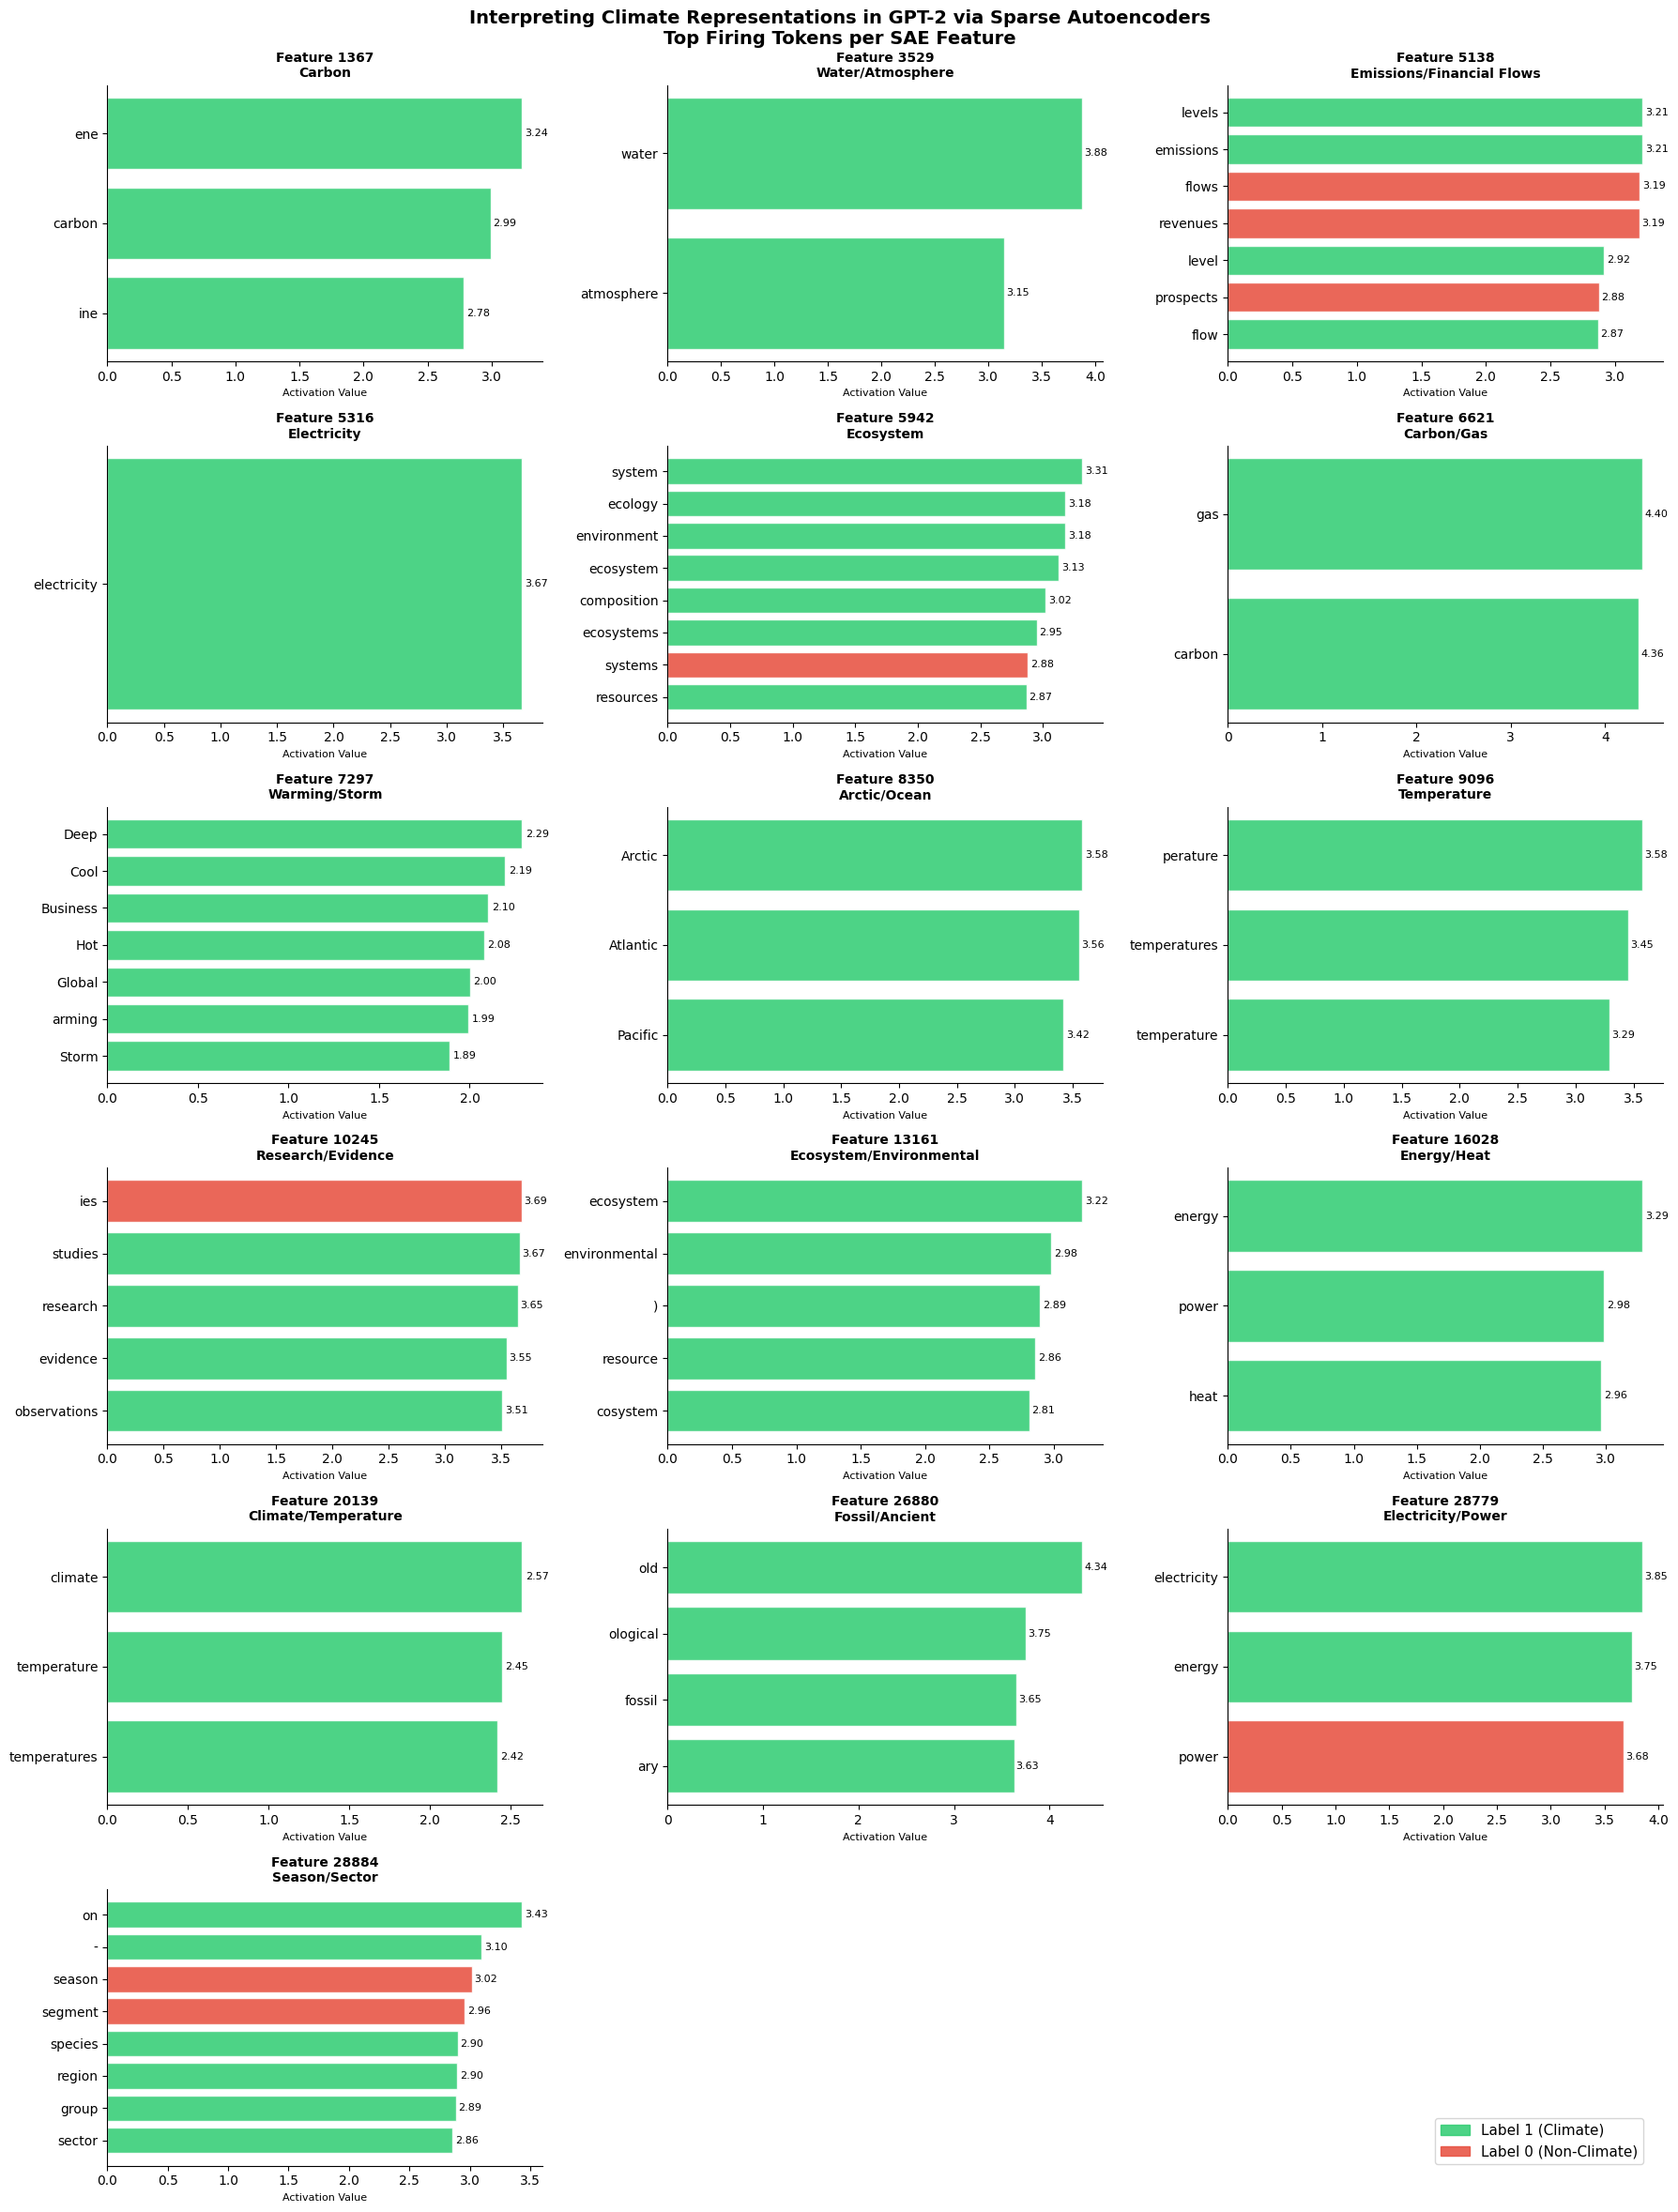

In [50]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

features_to_plot = df_tokens["feature_idx"].unique()
n_features       = len(features_to_plot)

# dynamic grid size
n_cols = 3
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(18, n_rows * 4))
fig.suptitle(
    "Interpreting Climate Representations in GPT-2 via Sparse Autoencoders\n"
    "Top Firing Tokens per SAE Feature\n",
    fontsize=14, fontweight="bold"
)
axes = axes.flatten()

color_map = {"Climate": "#2ecc71", "Non-Climate": "#e74c3c"}
colors = [color_map.get(l, "#e74c3c") for l in labels]

for plot_idx, feat_idx in enumerate(features_to_plot):
    ax        = axes[plot_idx]
    feat_data = df_tokens[df_tokens["feature_idx"] == feat_idx]
    feat_name = feat_data["feature_name"].iloc[0]

    tokens  = feat_data["token"].tolist()
    values  = feat_data["value"].tolist()
    labels  = feat_data["label_name"].tolist()
    colors  = [color_map[l] for l in labels]

    bars = ax.barh(range(len(tokens)), values,
                   color=colors, alpha=0.85, edgecolor="white")
    ax.set_yticks(range(len(tokens)))
    ax.set_yticklabels(tokens, fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel("Activation Value", fontsize=8)
    ax.set_title(f"Feature {feat_idx}\n{feat_name}",
                 fontsize=10, fontweight="bold")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # value labels on bars
    for bar, val in zip(bars, values):
        ax.text(bar.get_width() + 0.02,
                bar.get_y() + bar.get_height() / 2,
                f"{val:.2f}", va="center", fontsize=8)

# hide unused subplots
for i in range(len(features_to_plot), len(axes)):
    axes[i].set_visible(False)

# legend
climate_patch    = mpatches.Patch(color="#2ecc71", alpha=0.85,
                                   label="Label 1 (Climate)")
nonclimate_patch = mpatches.Patch(color="#e74c3c", alpha=0.85,
                                   label="Label 0 (Non-Climate)")
fig.legend(handles=[climate_patch, nonclimate_patch],
           loc="lower right", fontsize=11,
           bbox_to_anchor=(0.98, 0.02))

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/top_firing_tokens_from_df.png", dpi=150, bbox_inches="tight")
plt.show()